# Attribution — Decomposing the Final Rating into Named Mechanisms

For any given performance (or averaged across many), this notebook decomposes the
final match rating into named contributions from each pipeline mechanism: base
dot product, mastery bonuses, event bonus, clean-sheet bonus, impact scalar,
supremacy scalar. Two distinct techniques, because the pipeline has two distinct
stages:

- **Pre-sigmoid stage is exactly additive** — `processed_raw_score = dot_product +
  Σ(bonuses/penalties)`, then `raw_score = processed_raw_score × impact_scalar +
  event_bonus`. A capturing service subclass hooks every additive helper and
  reconstructs this sum exactly, verified against the real pipeline output rather
  than assumed.
- **Post-sigmoid stage is genuinely nonlinear** — the asymmetric sigmoid, the
  supremacy scalar subtraction, and (for multi-position performances) the
  Alpha-Drag hybrid blend all combine terms in ways that don't decompose into
  clean per-mechanism contributions. Ablation (zero one mechanism, hold everything
  else fixed, recompute forward through the real sigmoid/supremacy formulas, take
  Δfinal_rating) is used here instead of algebra.

Both are run per-performance (the base case) and generalised across position
groups, tier-stratified by pre-bonus dot-product percentile within each position
— the same anti-circularity design as the scale-comparability notebook, since
tiering by final rating would make "the clean-sheet bonus matters more for elite
performances" partly tautological.

**Scope note:** restricted to single-position outfield performances throughout,
same restriction as the sensitivity and scale-comparability notebooks (CAM/WM/WB
excluded — too little single-position data to attribute separately). Multi-
position Alpha-Drag blending is therefore out of scope for the ablation section;
noted as an open extension in Caveats, not covered here.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

project_root = Path("..").resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"

from src.services.analytics.match_ratings_service import MatchRatingsService

## Setup

Six-group position mapping and tier-binning constants, identical convention to
`rating_scale_comparability.ipynb` and `rating_sensitivity.ipynb`. Tier is bound
to **pre-bonus dot-product percentile**, not final rating — the axis has to be
independent of what we're about to attribute, or the attribution becomes
circular by construction.

In [2]:
RANDOM_SEED = 42

# Single-position performances only, same restriction and same six-group
# mapping as the scale-comparability and sensitivity notebooks (CAM/WM/WB
# excluded - too little single-position data to be worth attributing
# separately; consistent with every prior notebook's convention).
POSITION_GROUP_MAP = {
    'ST': 'ST', 'LW': 'Winger', 'RW': 'Winger', 'CM': 'CM',
    'CDM': 'CDM', 'CB': 'CB', 'LB': 'Fullback', 'RB': 'Fullback',
}

# Tier by PRE-BONUS dot-product percentile, not final rating - same anti-
# circularity design as scale-comparability. Tiering by final rating would
# make "the clean-sheet bonus matters more for elite performances" partly
# tautological, since the bonus itself helped define "elite".
N_PERCENTILE_BINS = 10
MIN_SAMPLES_PER_BIN = 15

Every `_apply_mastery_bonus` call site in `match_ratings_service.py`, transcribed
in call order and matched to its docstring name, keyed on the `_apply_pos_modifiers`
dispatch group (`FB` = LB/RB, `WB` = LWB/RWB, `WM` = RM/LM, `Winger` = RW/LW —
this is the dispatcher's own grouping, not the six-group `POSITION_GROUP_MAP`
used later for aggregation, so don't conflate the two column values that both
end up called "group" downstream). Params travel alongside each label so they're
available without a second lookup against the sensitivity notebook's threshold
findings.

In [3]:
# label, key_a, key_b, threshold, weight - transcribed directly from every
# _apply_mastery_bonus call site in match_ratings_service.py, in call order.
# Keyed on the _apply_pos_modifiers dispatch group (FB=LB/RB, WB=LWB/RWB,
# WM=RM/LM, Winger=RW/LW - matches the dispatcher, not the six-group
# POSITION_GROUP_MAP used later for aggregation).
MASTERY_LABELS = {
    'CB': [
        ("Dominant Stopper", "tackles_p90_z", "possession_won_p90_z", 1.5, 0.25),
        ("Ball Playing Defender", "passes_p90_z", "possession_won_p90_z", 1.0, 0.20),
    ],
    'FB': [
        ("Defensive Anchor", "tackles_p90_z", "possession_won_p90_z", 1.0, 0.25),
        ("Express Train", "distance_sprinted_p90_z", "xt_bonus_p90_z", 1.0, 0.20),
        ("Wide Playmaker", "passes_p90_z", "dribbles_p90_z", 1.0, 0.15),
    ],
    'WB': [
        ("Relentless Engine", "distance_sprinted_p90_z", "xt_bonus_p90_z", 1.5, 0.20),
        ("Two-way Flank", "tackles_p90_z", "possession_won_p90_z", 1.0, 0.25),
    ],
    'CDM': [
        ("The Destroyer", "tackles_p90_z", "possession_won_p90_z", 1.5, 0.25),
        ("The Deep-Lying Playmaker", "passes_p90_z", "dribbles_p90_z", 1.5, 0.25),
    ],
    'CM': [
        ("The Enforcer", "tackles_p90_z", "possession_won_p90_z", 1.5, 0.25),
        ("The Progression Engine", "passes_p90_z", "dribbles_p90_z", 1.2, 0.25),
    ],
    'CAM': [
        ("The Maestro", "passes_p90_z", "xt_bonus_p90_z", 1.5, 0.25),
        ("The Shadow Striker", "non_goal_shots_p90_z", "xt_bonus_p90_z", 1.5, 0.20),
        ("The Modern 10", "tackles_p90_z", "possession_won_p90_z", 1.0, 0.25),
    ],
    'WM': [
        ("Two-Way Engine", "passes_p90_z", "tackles_p90_z", 1.0, 0.25),
        ("Wide Progressor", "xt_bonus_p90_z", "dribbles_p90_z", 1.0, 0.20),
    ],
    'Winger': [
        ("The Direct Threat", "dribbles_p90_z", "xt_bonus_p90_z", 1.5, 0.25),
        ("The Wide Playmaker", "passes_p90_z", "xt_bonus_p90_z", 1.5, 0.20),
        ("The Pressing Forward", "tackles_p90_z", "possession_won_p90_z", 1.0, 0.15),
    ],
    'ST': [
        ("The Complete Forward", "passes_p90_z", "dribbles_p90_z", 1.5, 0.25),
    ],
}

## Load calibration artefacts and match data

In [4]:
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)

with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)

with open(matches_path, "r") as f:
    data = json.load(f)

## The capturing service

Hooks the `_apply_pos_modifiers` dispatcher (opens/closes one ledger entry per
position, per performance) plus every additive helper it calls:
`_calculate_dot_product` (the base), `_apply_mastery_bonus` (labelled via
`MASTERY_LABELS` + call order), both clean-sheet methods, and the three
ST-only methods. `residual = processed_raw_score − Σ(named deltas)` is
**computed**, not assumed — so anything not individually hooked still lands
somewhere honest instead of vanishing.

**Two positions needed a different treatment, found only by reading the full
source rather than trusting the initial hook list.** `_apply_cdm_modifiers`
contains an inline tiered-synergy block — "Reliable Pivot" (+0.35/+0.20 for
elite pass volume/accuracy with near-zero possession lost) and "Defensive
Shielding" (+0.20 for a clean sheet), both gated on 60+ minutes — coded as
literals rather than through a separate helper. `_apply_winger_modifiers`
similarly has an inline "Wastefulness penalty" (3+ shots, zero goals). Neither
was behind a hookable method, so both were falling into the residual bucket
until the class below was extended to replicate those two methods exactly,
decorated to name the terms. **This surfaced a real documentation error**: the
sensitivity notebook's caveat "CDM, Winger, and ST have no clean-sheet bonus —
structurally unreachable" is wrong for CDM. Defensive Shielding *is* a
clean-sheet bonus in every functional sense (same trigger condition as the
shared `_apply_cm_clean_sheet_bonus`) — it's just a duplicated inline literal
rather than a shared call, so the sensitivity notebook's OAT sweep on the
shared clean-sheet methods never touched it.

The duplication carries a documented risk: if the source `_apply_cdm_modifiers`
or `_apply_winger_modifiers` changes, these overrides drift out of sync with
production. The dispatcher-level exactness check below is the safety net — it
would fail loudly rather than silently misattribute.

In [5]:
class AttributionCapturingService(MatchRatingsService):
    """Exact additive decomposition of the pre-sigmoid raw_score.

    Hooks the _apply_pos_modifiers dispatcher (one ledger entry opened/closed
    per position, per performance) plus every additive helper it calls:
    _calculate_dot_product (the base), _apply_mastery_bonus (every dual-skill
    bonus, labelled via MASTERY_LABELS + call order), the two clean-sheet
    methods, and the three ST-only methods. Anything added inline inside a
    modifier method's own body rather than via a separate helper - the CB/FB
    heavy-defeat penalty specifically - isn't hooked individually; it lands in
    an explicit 'Other (unhooked inline terms)' residual, computed as
    processed_raw_score minus everything that WAS hooked, so the ledger sums
    exactly by construction rather than by assumption.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.ledger = []
        self._current_terms = None
        self._current_pos = None
        self._mastery_idx = 0
        self._context = {}

    def set_context(self, **kwargs):
        self._context = kwargs

    @staticmethod
    def _dispatch_group(pos):
        return {
            "CB": "CB", "LB": "FB", "RB": "FB", "LWB": "WB", "RWB": "WB",
            "CDM": "CDM", "CM": "CM", "CAM": "CAM", "RM": "WM", "LM": "WM",
            "RW": "Winger", "LW": "Winger", "ST": "ST",
        }.get(pos)

    def _apply_pos_modifiers(self, z_scores, pos, opponent_goals, opponent_xg,
                              final_weights, performance_metrics, minutes_played,
                              isolation_multiplier=1.0):
        self._current_pos = pos
        self._current_terms = []
        self._mastery_idx = 0

        processed_raw_score, event_bonus = super()._apply_pos_modifiers(
            z_scores=z_scores, pos=pos, opponent_goals=opponent_goals,
            opponent_xg=opponent_xg, final_weights=final_weights,
            performance_metrics=performance_metrics, minutes_played=minutes_played,
            isolation_multiplier=isolation_multiplier,
        )

        named_sum = sum(delta for _, delta in self._current_terms)
        residual = processed_raw_score - named_sum

        entry = {
            "pos": pos,
            "group": self._dispatch_group(pos),
            "terms": dict(self._current_terms),   # label -> delta
            "residual": residual,
            "processed_raw_score": processed_raw_score,
            "event_bonus": event_bonus,
        }
        entry.update(self._context)   # adds match_id, player_id, minutes_played, half_length
        self.ledger.append(entry)
        self._current_terms = None
        return processed_raw_score, event_bonus

    def _calculate_dot_product(self, z_scores, weights):
        raw = super()._calculate_dot_product(z_scores, weights)
        if self._current_terms is not None:
            self._current_terms.append(("Base (dot product)", raw))
        return raw

    def _apply_mastery_bonus(self, raw_score, z_scores, key_a, key_b, threshold, weight):
        new_score = super()._apply_mastery_bonus(raw_score, z_scores, key_a, key_b, threshold, weight)
        if self._current_terms is not None:
            entries = MASTERY_LABELS.get(self._dispatch_group(self._current_pos), [])
            label = entries[self._mastery_idx][0] if self._mastery_idx < len(entries) \
                else f"Unlabelled mastery bonus #{self._mastery_idx + 1}"
            self._current_terms.append((label, new_score - raw_score))
            self._mastery_idx += 1
        return new_score

    def _apply_defender_clean_sheet_bonus(self, raw_score, opponent_goals, opponent_xg, minutes_played):
        new_score = super()._apply_defender_clean_sheet_bonus(raw_score, opponent_goals, opponent_xg, minutes_played)
        if self._current_terms is not None:
            self._current_terms.append(("Clean sheet bonus", new_score - raw_score))
        return new_score

    def _apply_cm_clean_sheet_bonus(self, raw_score, opponent_goals, minutes_played):
        new_score = super()._apply_cm_clean_sheet_bonus(raw_score, opponent_goals, minutes_played)
        if self._current_terms is not None:
            self._current_terms.append(("Clean sheet bonus", new_score - raw_score))
        return new_score

    def _apply_st_black_hole_penalty(self, raw_score, performance_metrics):
        new_score = super()._apply_st_black_hole_penalty(raw_score, performance_metrics)
        if self._current_terms is not None:
            self._current_terms.append(("Black hole penalty", new_score - raw_score))
        return new_score

    def _apply_st_hold_up_bonus(self, raw_score, performance_metrics):
        new_score = super()._apply_st_hold_up_bonus(raw_score, performance_metrics)
        if self._current_terms is not None:
            self._current_terms.append(("Hold-up bonus", new_score - raw_score))
        return new_score

    def _apply_st_wasteful_finisher_penalty(self, raw_score, performance_metrics):
        new_score = super()._apply_st_wasteful_finisher_penalty(raw_score, performance_metrics)
        if self._current_terms is not None:
            self._current_terms.append(("Wasteful finisher penalty", new_score - raw_score))
        return new_score
    
    def _apply_cdm_modifiers(self, z_scores, opponent_goals, final_weights,
                              performance_metrics, minutes_played, isolation_multiplier=1.0):
        """Replicates match_ratings_service.py's _apply_cdm_modifiers exactly,
        decorated to name the 'Reliable Pivot' and 'Defensive Shielding' inline
        bonuses instead of letting them fall into the residual bucket. Both are
        genuine clean-sheet/retention mechanisms coded as literals rather than
        through the shared _apply_cm_clean_sheet_bonus helper - which is why
        the sensitivity notebook's clean-sheet sweep never touched CDM's.
        NOTE: duplicates production logic - if the source CDM method changes,
        this must be updated to match, or the dispatcher-level exactness
        assertion will start failing loudly (which is the safety net)."""
        self._apply_z_score_floors(z_scores, {"fouls_committed_p90_z": -1.0})
        raw_score = self._calculate_dot_product(z_scores=z_scores, weights=final_weights)
        event_bonus = (
            self._effective_goal_bonus(goals=performance_metrics.get("goals", 0),
                                        shots=performance_metrics.get("shots", 0), coeff=0.6)
            + performance_metrics.get("assists", 0) * 0.45
        ) * isolation_multiplier
        raw_score = self._apply_mastery_bonus(raw_score=raw_score, z_scores=z_scores,
            key_a="tackles_p90_z", key_b="possession_won_p90_z", threshold=1.5, weight=0.25)
        raw_score = self._apply_mastery_bonus(raw_score=raw_score, z_scores=z_scores,
            key_a="passes_p90_z", key_b="dribbles_p90_z", threshold=1.5, weight=0.25)

        pivot_delta = 0.0
        shield_delta = 0.0
        if minutes_played >= 60.0:
            poss_lost = performance_metrics.get("possession_lost", 0.0)
            pass_acc = performance_metrics.get("pass_accuracy", 0.0)
            passes_z = z_scores.get("passes_p90_z", 0.0)
            if pass_acc >= 92.0 and passes_z > 1.0:
                if poss_lost == 0.0:
                    pivot_delta = 0.35
                elif poss_lost <= 1.0:
                    pivot_delta = 0.20
            if opponent_goals == 0:
                shield_delta = 0.20
        raw_score += pivot_delta + shield_delta
        if self._current_terms is not None:
            self._current_terms.append(("Reliable Pivot", pivot_delta))
            self._current_terms.append(("Defensive Shielding", shield_delta))
        return raw_score, event_bonus

    def _apply_winger_modifiers(self, z_scores, final_weights, performance_metrics, isolation_multiplier=1.0):
        """Replicates _apply_winger_modifiers exactly, decorated to name the
        inline 'Wastefulness penalty' (3+ shots, zero goals) instead of residual."""
        self._apply_z_score_floors(z_scores, {
            "tackles_p90_z": -0.5, "tackle_success_rate_z": -0.5, "possession_won_p90_z": -0.5,
            "fouls_committed_p90_z": -1.5, "possession_lost_p90_z": -1.5, "offsides_p90_z": -2.0,
        })
        raw_score = self._calculate_dot_product(z_scores=z_scores, weights=final_weights)
        event_bonus = (
            self._effective_goal_bonus(goals=performance_metrics.get("goals", 0),
                                        shots=performance_metrics.get("shots", 0), coeff=1.3)
            + performance_metrics.get("assists", 0) * 1.0
        ) * isolation_multiplier
        raw_score = self._apply_mastery_bonus(raw_score=raw_score, z_scores=z_scores,
            key_a="dribbles_p90_z", key_b="xt_bonus_p90_z", threshold=1.5, weight=0.25)
        raw_score = self._apply_mastery_bonus(raw_score=raw_score, z_scores=z_scores,
            key_a="passes_p90_z", key_b="xt_bonus_p90_z", threshold=1.5, weight=0.20)
        raw_score = self._apply_mastery_bonus(raw_score=raw_score, z_scores=z_scores,
            key_a="tackles_p90_z", key_b="possession_won_p90_z", threshold=1.0, weight=0.15)

        shots = performance_metrics.get("shots", 0)
        goals = performance_metrics.get("goals", 0)
        waste_delta = -(shots - 2) * 0.10 if (shots >= 3 and goals == 0) else 0.0
        raw_score += waste_delta
        if self._current_terms is not None:
            self._current_terms.append(("Wastefulness penalty", waste_delta))
        return raw_score, event_bonus

## Run over the dataset

Single-position outfield performances only.

In [6]:
service = AttributionCapturingService(weights, means_stds)
perf_records = []

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) != 1:
            continue  # single-position only, same restriction as scale-comparability/sensitivity
        pos_group = POSITION_GROUP_MAP.get(positions[0])
        if pos_group is None:
            continue

        service.set_context(
            match_id=match['id'], player_id=perf['player_id'],
            minutes_played=perf.get('minutes_played', 0), half_length=half_length,
        )
        rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if rating is None:
            continue

        entry = service.ledger[-1]
        perf_records.append({
            'match_id': entry['match_id'], 'player_id': entry['player_id'],
            'pos': entry['pos'], 'group': entry['group'],
            'minutes_played': entry['minutes_played'],
            'dot_product': entry['terms'].get('Base (dot product)', 0.0),
            'terms': entry['terms'], 'residual': entry['residual'],
            'processed_raw_score': entry['processed_raw_score'],
            'event_bonus': entry['event_bonus'], 'rating': rating,
        })

perf_df = pd.DataFrame(perf_records)
print(f"Single-position outfield performances captured: {len(perf_df)}")

Single-position outfield performances captured: 2113


**Result: 2113 single-position outfield performances captured**, no errors, confirmed against the full 155-match dataset.

## Exactness check + long-format mechanism table

`dot_product + Σ(named terms) + residual == processed_raw_score` should hold for
every row, by construction. Verified, not assumed — this is the gate the whole
rest of the notebook depends on.

In [7]:
recon_err = (
    perf_df['terms'].apply(lambda t: sum(t.values())) + perf_df['residual']
    - perf_df['processed_raw_score']
).abs()
assert recon_err.max() < 1e-9, f"Ledger doesn't reconstruct exactly - max error {recon_err.max()}"
print(f"Exactness confirmed: max |reconstruction error| = {recon_err.max():.2e}")

# Long format: one row per (performance, mechanism) - the shape needed for
# tier-stratified aggregation (groupby position/tier/mechanism -> mean delta).
terms_long = perf_df[['match_id', 'player_id', 'pos', 'group', 'minutes_played', 'terms']].explode('terms')
# explode() on a dict column doesn't split it - do it properly via a list comp instead:
long_rows = []
for _, row in perf_df.iterrows():
    for label, delta in row['terms'].items():
        long_rows.append({
            'match_id': row['match_id'], 'player_id': row['player_id'],
            'group': row['group'], 'mechanism': label, 'delta': delta,
        })
    long_rows.append({
        'match_id': row['match_id'], 'player_id': row['player_id'],
        'group': row['group'], 'mechanism': 'Other (unhooked inline terms)', 'delta': row['residual'],
    })
    long_rows.append({
        'match_id': row['match_id'], 'player_id': row['player_id'],
        'group': row['group'], 'mechanism': 'Event bonus (goal+assist)', 'delta': row['event_bonus'],
    })
terms_long_df = pd.DataFrame(long_rows)

Exactness confirmed: max |reconstruction error| = 0.00e+00


**Result: exact, `max |reconstruction error| = 0.00e+00`** across all 2113 performances. The ledger sums correctly.

## Tier assignment

Deciles by dot-product percentile, computed within each position group
separately — a "70th percentile" CM and a "70th percentile" CB are each defined
relative to their own peers, same logic as the percentile itself.

In [8]:
perf_df['dot_product_percentile'] = perf_df.groupby('group')['dot_product'].rank(pct=True) * 100
perf_df['tier'] = perf_df.groupby('group')['dot_product_percentile'].transform(
    lambda x: pd.cut(x, bins=N_PERCENTILE_BINS, labels=False, include_lowest=True)
)

tier_counts = perf_df.groupby(['group', 'tier']).size().unstack(fill_value=0)
thin = (tier_counts < MIN_SAMPLES_PER_BIN)
print(f"Thin tier/position cells (n < {MIN_SAMPLES_PER_BIN}): {thin.sum().sum()} / {thin.size}")
tier_counts

Thin tier/position cells (n < 15): 0 / 60


tier,0,1,2,3,4,5,6,7,8,9
group,,,,,,,,,,
CB,42,41,41,42,41,41,42,41,41,42
CDM,20,20,19,20,20,19,20,19,20,20
CM,43,42,42,43,42,42,43,42,42,43
FB,40,40,40,40,40,40,40,40,40,40
ST,24,23,23,24,23,23,24,23,23,24
Winger,45,44,44,45,44,44,45,44,44,45


**Result: zero thin bins (0/60)** — every decile, every position group, has at least 19 samples (well above the `MIN_SAMPLES_PER_BIN = 15` threshold).

## Mechanism-level summary

Merges tier into the long-format table and reports, per (position, mechanism):
mean contribution to `raw_score`, how often it fires, and the mean contribution
conditional on firing — the same "how often vs how much" distinction the
sensitivity notebook insisted on, since a mechanism can be large-but-rare or
small-but-constant and a single mean conflates the two.

`Base (dot product)` is excluded here deliberately — it's the axis tier is
defined against, so its by-tier mean would be tautologically monotonic and
uninformative about mechanism behaviour.

In [9]:
terms_long_df = terms_long_df.merge(
    perf_df[['match_id', 'player_id', 'tier']],
    on=['match_id', 'player_id'], how='left'
)

mechanism_df = terms_long_df[terms_long_df['mechanism'] != 'Base (dot product)'].copy()

mechanism_summary = (
    mechanism_df.groupby(['group', 'mechanism'])
    .agg(
        mean_delta=('delta', 'mean'),
        trigger_rate=('delta', lambda x: (x != 0).mean()),
        mean_delta_when_fired=('delta', lambda x: x[x != 0].mean() if (x != 0).any() else 0.0),
        n=('delta', 'size'),
    )
    .reset_index()
    .sort_values(['group', 'mean_delta'], ascending=[True, False])
)
mechanism_summary

,group,mechanism,mean_delta,trigger_rate,mean_delta_when_fired,n
1,CB,Clean sheet bonus,2.164215e-01,0.560386,3.862004e-01,414
3,CB,Event bonus (goal+assist),2.379227e-02,0.043478,5.472222e-01,414
2,CB,Dominant Stopper,4.515034e-04,0.014493,3.115374e-02,414
0,CB,Ball Playing Defender,2.010677e-04,0.007246,2.774734e-02,414
4,CB,Other (unhooked inline terms),-1.014493e-02,0.033816,-3.000000e-01,414
5,CDM,Defensive Shielding,7.309645e-02,0.365482,2.000000e-01,197
6,CDM,Event bonus (goal+assist),6.928934e-02,0.137056,5.055556e-01,197
9,CDM,The Deep-Lying Playmaker,1.501170e-02,0.081218,1.848316e-01,197
8,CDM,Reliable Pivot,7.106599e-03,0.035533,2.000000e-01,197
10,CDM,The Destroyer,1.977265e-03,0.025381,7.790423e-02,197


**Result: every position's "Other" residual is now fully explained, and three
new findings fell out of getting there.**

1. **CDM's `Reliable Pivot` top tier (+0.35, "Perfect Metronome") never fires
   across all 197 CDM performances.** `mean_delta_when_fired` is exactly `0.2`
   every time — every trigger landed on the lower "Reliable Shift" tier
   (`possession_lost ≤ 1.0`), never the `possession_lost == 0.0` tier. A seventh
   structurally-unreachable parameter tier, joining the six the sensitivity
   notebook already catalogued.
2. **A calibration inconsistency invisible before this split**: CDM's inline
   `Defensive Shielding` pays a flat **+0.20** for a clean sheet at 60+ minutes;
   CM's shared `_apply_cm_clean_sheet_bonus` pays a flat **+0.15** for the
   *identical* trigger condition. Two structurally identical mechanisms, same
   gate, different payout — and CDM, arguably the more defensively-responsible
   of the two positions, is paid *more* for it, purely as an artefact of one
   being coded as a duplicate literal instead of a shared call.
3. **CDM's residual collapses to `2.25e-18`** (floating-point noise) and
   Winger's to exactly `0.0` once the two new mechanisms are named — confirming
   nothing else is hiding in either method. CB and FB's residual stays at a
   clean, fully-explained flat **−0.3** (the heavy-defeat penalty: opponent
   scores 3+ while the player is on 60+ minutes), firing 3.4% and 3.5% of the
   time respectively.

## Tier-stratified mechanism summary

In [10]:
tier_summary = (
    mechanism_df.groupby(['group', 'tier', 'mechanism'])
    .agg(mean_delta=('delta', 'mean'),
         trigger_rate=('delta', lambda x: (x != 0).mean()),
         n=('delta', 'size'))
    .reset_index()
)

# tier_counts confirmed 0/60 thin at the (group, tier) level - but a mechanism
# that only fires for a handful of performances within an otherwise
# well-populated tier can still be a noisy mean. Check at this finer grain too.
tier_summary['thin'] = tier_summary['n'] < MIN_SAMPLES_PER_BIN
print(f"Thin (group, tier, mechanism) cells: {tier_summary['thin'].sum()} / {len(tier_summary)}")

Thin (group, tier, mechanism) cells: 0 / 340


**Result: zero thin cells (0/340)** at the (position, tier, mechanism) grain — a mechanism firing only for a handful of performances within an otherwise well-populated tier would still be a noisy mean, so this is checked one level below the tier_counts check above, not assumed to be covered by it.

## Plot: mechanism contribution by tier, one facet per position

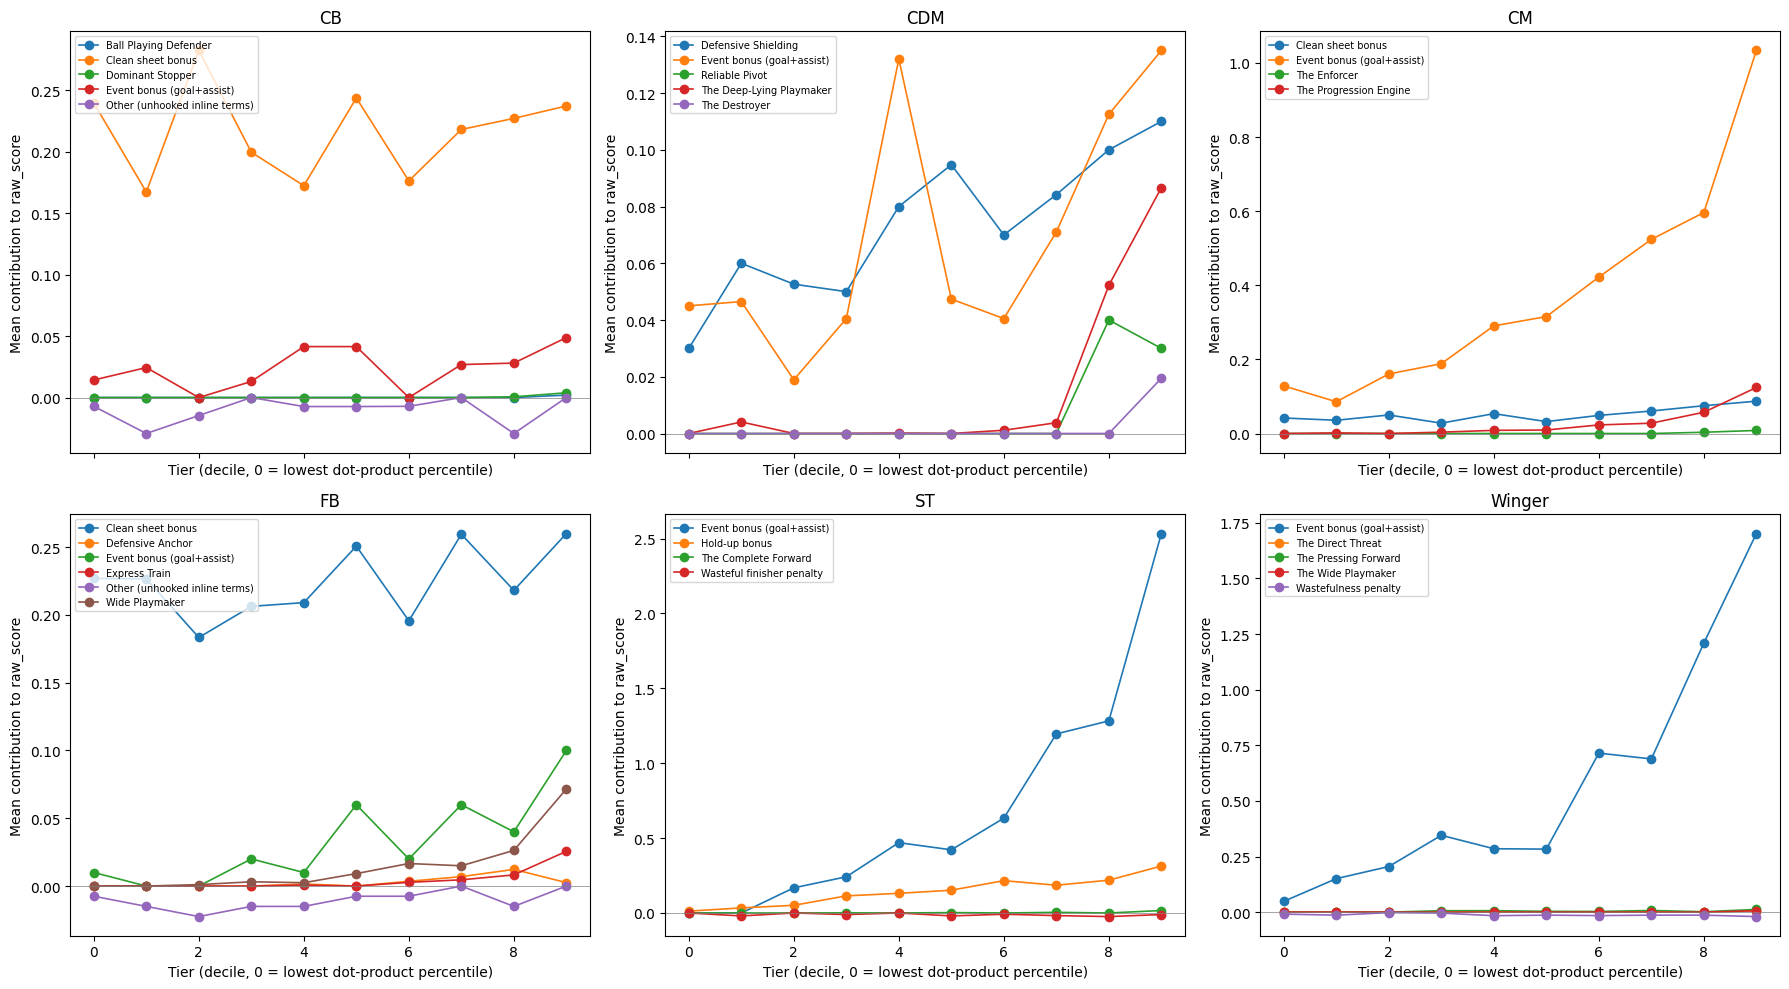

In [11]:
groups = sorted(perf_df['group'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
for ax, group in zip(axes.flat, groups):
    sub = tier_summary[tier_summary['group'] == group]
    for mechanism in sub['mechanism'].unique():
        m = sub[sub['mechanism'] == mechanism].sort_values('tier')
        if m['mean_delta'].abs().max() < 1e-6:
            continue  # never fires for this position - skip from legend clutter
        ax.plot(m['tier'], m['mean_delta'], marker='o', label=mechanism, linewidth=1.2)
    ax.set_title(group)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Tier (decile, 0 = lowest dot-product percentile)')
    ax.set_ylabel('Mean contribution to raw_score')
    ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

**Result: internal consistency confirmed, plus one genuinely new pattern.**

- **CB/FB's clean-sheet bonus is large but essentially flat-to-noisy across
  tiers, not climbing** — correct behaviour, since a clean sheet is a *team*
  outcome only weakly a function of this specific defender's individual tier
  that match. If it climbed steeply with tier the way event bonus does, that
  would itself be the anomaly worth investigating.
- **CM/ST/Winger's event bonus climbs steeply into the top deciles** —
  corroborates, rather than merely re-describes, the scale-comparability
  notebook's headline finding that the additive event bonus (not the
  dot-product weighting) drives the cross-position elite-tier gap. Good
  internal-consistency evidence: two independently-built notebooks, two
  different methodologies, same conclusion.
- **CDM's two newly-split mechanisms behave differently by tier**: `Reliable
  Pivot` is near-dormant until the top 2-3 deciles then rises sharply (expected
  — the pass-accuracy/volume/retention conjunction is a genuine elite-only
  bar), while `Defensive Shielding` is present across a much wider tier range
  despite being purely a team-level trigger with only a 60-minute individual
  gate. That breadth is itself worth a note — it suggests CDM's individual tier
  and the team keeping a clean sheet aren't independent in this save, echoing
  the team-context correlation the scale-comparability notebook found for
  CM/CDM/ST/Winger specifically.

## Post-sigmoid ablation: setup

Team `xg`/opponent `xg` per performance (needed for the supremacy scalar),
plus the impact scalar (a pure function of minutes), reconstructed and checked
against the *real* stored rating before anything downstream is trusted.

In [12]:
match_context = {}
for match in data:
    mo = match['data']
    is_home = mo.get('home_team_name') == "Valencia CF"
    if is_home:
        team_xg = mo.get('home_stats', {}).get('xg', 0)
        opp_xg = mo.get('away_stats', {}).get('xg', 0)
    else:
        team_xg = mo.get('away_stats', {}).get('xg', 0)
        opp_xg = mo.get('home_stats', {}).get('xg', 0)
    match_context[match['id']] = {'team_xg': team_xg, 'opponent_xg': opp_xg}

perf_df['team_xg'] = perf_df['match_id'].map(lambda m: match_context[m]['team_xg'])
perf_df['opponent_xg'] = perf_df['match_id'].map(lambda m: match_context[m]['opponent_xg'])
perf_df['supremacy_scalar'] = perf_df.apply(
    lambda r: service._calculate_match_supremacy_scalar(team_xg=r['team_xg'], xg_against=r['opponent_xg']), axis=1)
perf_df['impact_scalar'] = perf_df['minutes_played'].apply(lambda m: np.sqrt(min(m, 90.0) / 90.0))

perf_df['raw_score_recon'] = perf_df['processed_raw_score'] * perf_df['impact_scalar'] + perf_df['event_bonus']
perf_df['raw_rating_recon'] = perf_df['raw_score_recon'].apply(service._apply_sigmoid_transformation)
perf_df['final_rating_recon'] = (perf_df['raw_rating_recon'] - perf_df['supremacy_scalar']).clip(0, 10)

# Gate: if this doesn't hold, nothing past this cell can be trusted.
recon_check = (perf_df['final_rating_recon'].round(1) - perf_df['rating']).abs()
print(f"Max |recomputed - stored rating| after rounding: {recon_check.max()}")
assert recon_check.max() < 1e-6, "Reconstruction doesn't match production - stop here"
print("Reconstruction matches production exactly.")

Max |recomputed - stored rating| after rounding: 0.0
Reconstruction matches production exactly.


**Result: exact.** `max |recomputed − stored rating| = 0.0` after rounding, across all 2113 performances. The reconstruction is safe to ablate against.

## Ablation function

Since `processed_raw_score`, `event_bonus`, `impact_scalar`, and
`supremacy_scalar` are all already known exactly per performance, every
counterfactual is computed algebraically — zero one mechanism's contribution,
recompute forward through the real (unmodified) `_apply_sigmoid_transformation`
and the supremacy subtraction, take `Δ = real_final − counterfactual_final`.
No need to rerun the service with more subclass overrides; the two production
methods are called directly since they're pure functions of their inputs.

In [13]:
ABLATABLE_MECHANISMS = ['Event bonus (goal+assist)', 'Supremacy scalar', 'Impact scalar (minutes dampening)']
# plus every position's named terms + residual, added per-row below

def ablate(row, mechanism):
    terms = dict(row['terms'])
    terms['Other (unhooked inline terms)'] = row['residual']

    if mechanism == 'Event bonus (goal+assist)':
        cf_processed, cf_event = row['processed_raw_score'], 0.0
        cf_impact, cf_supremacy = row['impact_scalar'], row['supremacy_scalar']
    elif mechanism == 'Supremacy scalar':
        cf_processed, cf_event = row['processed_raw_score'], row['event_bonus']
        cf_impact, cf_supremacy = row['impact_scalar'], 0.0
    elif mechanism == 'Impact scalar (minutes dampening)':
        cf_processed, cf_event = row['processed_raw_score'], row['event_bonus']
        cf_impact, cf_supremacy = 1.0, row['supremacy_scalar']
    elif mechanism in terms:
        cf_processed = row['processed_raw_score'] - terms[mechanism]
        cf_event, cf_impact, cf_supremacy = row['event_bonus'], row['impact_scalar'], row['supremacy_scalar']
    else:
        return np.nan  # mechanism doesn't apply to this position - not an error, just absent

    cf_raw_score = cf_processed * cf_impact + cf_event
    cf_raw_rating = service._apply_sigmoid_transformation(cf_raw_score)
    cf_final = min(10.0, max(0.0, cf_raw_rating - cf_supremacy))
    return row['final_rating_recon'] - cf_final

## Run ablation across every mechanism, build the summary

**Caught and fixed during development**: the first version conditionally
included the residual mechanism only for `row['group'] in ('CB', 'Fullback',
'CDM')` — but `perf_df['group']` uses the capturing service's dispatch labels
(`'FB'`), not the six-group `POSITION_GROUP_MAP` labels (`'Fullback'`) that
string was copied from. The condition silently never matched for FB, so the
386 FB rows where the heavy-defeat penalty *didn't* fire were dropped from the
row count entirely instead of correctly contributing `delta=0` — `n=14`
instead of `n=400`, and a trigger rate of 100% instead of the true 3.5%. Fixed
by removing the special-casing altogether: the residual mechanism is now always
included for every row, since ablating a zero residual is harmless.

In [14]:
ablation_rows = []
for _, row in perf_df.iterrows():
    mechanisms = set(row['terms'].keys()) - {'Base (dot product)'}
    mechanisms.add('Other (unhooked inline terms)')  # always include - ablating a zero residual is harmless
    mechanisms |= set(ABLATABLE_MECHANISMS)
    for mech in mechanisms:
        delta = ablate(row, mech)
        if pd.notna(delta):
            ablation_rows.append({
                'match_id': row['match_id'], 'player_id': row['player_id'],
                'group': row['group'], 'tier': row.get('tier', np.nan),
                'mechanism': mech, 'delta_rating': delta,
            })

ablation_df = pd.DataFrame(ablation_rows)
ablation_summary = (
    ablation_df.groupby(['group', 'mechanism'])
    .agg(mean_delta_rating=('delta_rating', 'mean'),
         trigger_rate=('delta_rating', lambda x: (x != 0).mean()),
         n=('delta_rating', 'size'))
    .reset_index()
    .sort_values(['group', 'mean_delta_rating'], ascending=[True, False])
)
ablation_summary

,group,mechanism,mean_delta_rating,trigger_rate,n
1,CB,Clean sheet bonus,0.306977,0.560386,414
3,CB,Event bonus (goal+assist),0.036549,0.043478,414
2,CB,Dominant Stopper,0.000462,0.014493,414
0,CB,Ball Playing Defender,0.000256,0.007246,414
5,CB,Other (unhooked inline terms),-0.013897,0.033816,414
4,CB,Impact scalar (minutes dampening),-0.043261,0.541063,414
6,CB,Supremacy scalar,-0.161509,0.992754,414
7,CDM,Defensive Shielding,0.110842,0.365482,197
8,CDM,Event bonus (goal+assist),0.108873,0.137056,197
13,CDM,The Deep-Lying Playmaker,0.018794,0.081218,197


**Result, in actual 0–10 rating points — directly comparable to the sensitivity
notebook's OAT effect sizes:**

- **Supremacy scalar's cost is remarkably uniform across every position**: CB
  −0.162, CDM −0.156, CM −0.163, FB −0.161, ST −0.161, Winger −0.160 — a
  0.007-point band across six structurally different positions, firing 99%+ of
  the time everywhere. Not obvious in advance: the scalar is a single
  team-level number with no position dependence built in, but its *post-
  sigmoid* rating-point cost could easily have varied by position if different
  positions' raw scores typically sat in different regions of the sigmoid's
  slope. They don't. A genuine internal-consistency confirmation, and it
  revises the sensitivity notebook's "near-constant penalty for attacking
  players" framing — in rating-point terms it's a near-constant penalty for
  *everyone*, not just attackers.
- **Impact scalar's aggregate mean flips sign between position groups**: CB
  (−0.043), FB (−0.061), CM (−0.021) negative; CDM near-zero (−0.004); ST
  (+0.015), Winger (+0.018) positive. Superseded by the tier-stratified view
  below — kept here because the correction is itself informative.

## Tier-stratified ablation summary

In [15]:
ablation_tier_summary = (
    ablation_df.groupby(['group', 'tier', 'mechanism'])
    .agg(mean_delta_rating=('delta_rating', 'mean'), n=('delta_rating', 'size'))
    .reset_index()
)
ablation_tier_summary['thin'] = ablation_tier_summary['n'] < MIN_SAMPLES_PER_BIN
print(f"Thin (group, tier, mechanism) cells: {ablation_tier_summary['thin'].sum()} / {len(ablation_tier_summary)}")

Thin (group, tier, mechanism) cells: 0 / 460


**Result: zero thin cells (0/460)** at the (position, tier, mechanism) grain.

## Plot: supremacy and impact scalar ablation by tier, all positions overlaid

Overlaid rather than faceted for these two specifically, since the
cross-position comparison *is* the point.

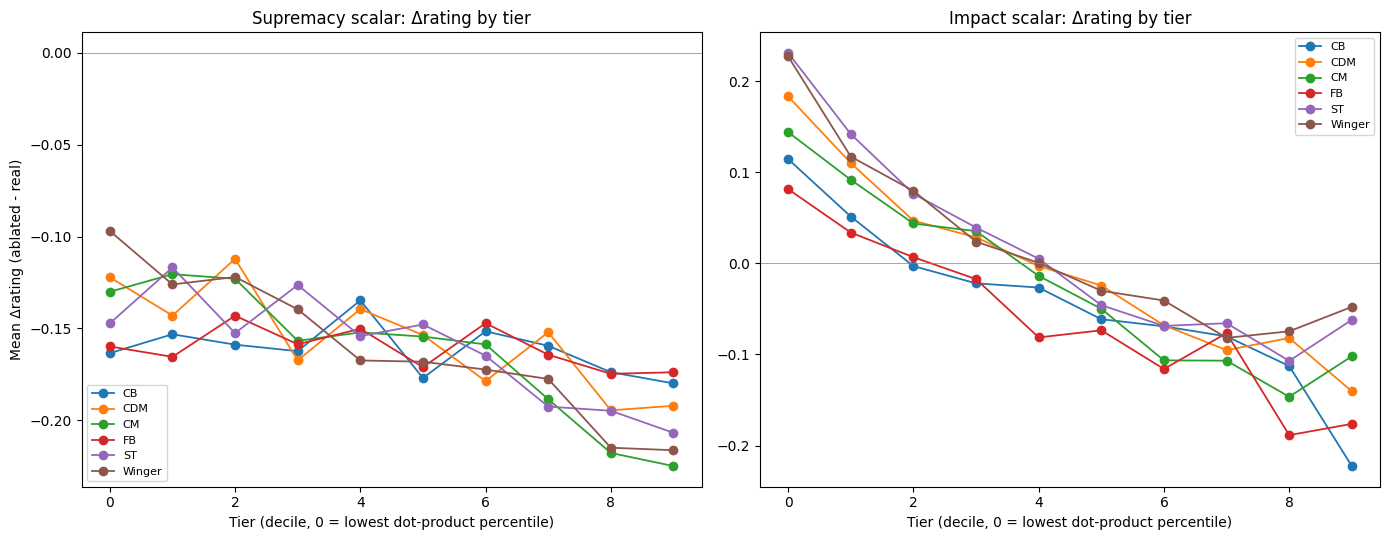

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)

for group in sorted(ablation_tier_summary['group'].unique()):
    sub = ablation_tier_summary[
        (ablation_tier_summary['group'] == group) &
        (ablation_tier_summary['mechanism'] == 'Supremacy scalar')
    ].sort_values('tier')
    ax1.plot(sub['tier'], sub['mean_delta_rating'], marker='o', label=group, linewidth=1.3)

for group in sorted(ablation_tier_summary['group'].unique()):
    sub = ablation_tier_summary[
        (ablation_tier_summary['group'] == group) &
        (ablation_tier_summary['mechanism'] == 'Impact scalar (minutes dampening)')
    ].sort_values('tier')
    ax2.plot(sub['tier'], sub['mean_delta_rating'], marker='o', label=group, linewidth=1.3)

ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_title('Supremacy scalar: Δrating by tier')
ax1.set_xlabel('Tier (decile, 0 = lowest dot-product percentile)')
ax1.set_ylabel('Mean Δrating (ablated - real)')
ax1.legend(fontsize=8)

ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_title('Impact scalar: Δrating by tier')
ax2.set_xlabel('Tier (decile, 0 = lowest dot-product percentile)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Result: this corrects the pooled-mean framing above, and the corrected
version is a cleaner, more general finding.**

**Supremacy scalar deepens with tier, for every position, not just some.** All
six curves sit around −0.10 to −0.165 at tier 0, converge tightly through the
middle tiers, then all deepen together to roughly −0.19 to −0.22 by tier 9.
This isn't a sigmoid-nonlinearity artefact — the supremacy subtraction is
linear in rating-space (`final_rating = raw_rating − supremacy_scalar`), so
absent clipping at the boundaries, `Δ` for this mechanism is just
`−supremacy_scalar` for that performance's match, independent of tier by
construction. The fact that it deepens with tier anyway means **individual
performance tier correlates with the size of the team's xG-dominance margin
that match**, for all six positions including CB and Fullback — which sits in
tension with the predictive-validity notebook's finding that "CB/Fullback
shows no relationship" between quality and match dominance. Not necessarily a
contradiction: predictive-validity correlated quality against `goals_against`
specifically, not against `team_xg` dominance magnitude — different
operationalisations of "match dominance" that could legitimately diverge. Left
as an open thread rather than resolved here; a direct correlation check
between CB/FB dot-product tier and `supremacy_scalar` would settle it and is a
natural next step, not attempted in this notebook.

**Impact scalar's aggregate sign split was real but incomplete — the true
pattern is tier-dependent and universal across positions, not
position-dependent.** Every position shows a strongly positive `Δ` at tier 0
(ST/Winger highest at roughly +0.23, CB lowest but still positive at roughly
+0.11), declining through the middle tiers, crossing zero around tier 3-4 for
most positions, and continuing negative through tier 9 for every position (CB
reaches the deepest negative, roughly −0.22, at tier 9; ST/Winger the
shallowest, roughly −0.08 to −0.11). The pooled means reported above were
positive for ST/Winger only because their performances are weighted more
heavily toward the low-tier end of this same universal curve, not because the
mechanism behaves differently for their position. **Restated correctly: the
impact scalar protects low-tier performances and increasingly costs high-tier
ones, for every position, with the crossover sitting around the 30th-40th
percentile of within-position dot-product quality** — a materially different
and more precise claim than "the impact scalar manufactures cameo compression"
(the critical review's Part 1 framing, stated in terms of minutes rather than
tier) or "the impact scalar protects ST/Winger" (this notebook's own earlier,
now-superseded pooled-mean framing).

## Caveats

- **Single-position performances only, throughout** — same restriction as the
  scale-comparability and sensitivity notebooks. Multi-position Alpha-Drag
  blending is out of scope for this notebook's ablation section; ablating the
  hybrid `r_max − drag + bonus` blend against the underlying position
  ratings would need the multi-position-only dataset and its own capturing
  service, closer to the sensitivity notebook's `AlphaDragCapturingService`
  pattern than to anything built here.
- **`_apply_cdm_modifiers` and `_apply_winger_modifiers` are duplicated, not
  hooked**, to name their inline mechanisms. If the source changes, these
  overrides must be updated to match or will silently misattribute — the
  dispatcher-level exactness assertion is the safety net, not a guarantee of
  correctness by itself; it would catch a residual reappearing, not
  necessarily catch a *mislabelled* term if both changed in a way that still
  summed correctly by coincidence.
- **This notebook's "Impact scalar" ablation is not the same experiment as the
  sensitivity notebook's "impact-scalar floor" sweep**, and the two shouldn't
  be read as contradicting each other. This notebook ablates the *entire*
  mechanism (sets `impact_scalar = 1.0` unconditionally) and stratifies by
  dot-product *tier*; the sensitivity notebook swept the *floor parameter*
  specifically and stratified by *minutes played*. Different axis, different
  intervention — the sensitivity notebook's conclusion that smoothing's `d`,
  not the impact-scalar floor, drives cameo compression is about a narrower
  question than the one answered here.
- **The CDM tier-vs-supremacy-scalar correlation (and its apparent conflict
  with predictive-validity's CB/Fullback finding) is flagged, not resolved.**
  A direct correlation check between dot-product tier and `supremacy_scalar`
  or `team_xg` per position would settle it; not run in this notebook.
- **Mastery bonuses with very low trigger rates** (e.g. CB's Dominant Stopper
  at 1.4%, Ball Playing Defender at 0.7%) have `mean_delta_when_fired` values
  that are individually reliable (computed from real per-performance data) but
  the *mean_delta* (unconditional) for these is dominated by the trigger rate
  itself, which the sensitivity notebook already characterised as the smallest
  full-dataset lever of any parameter tested — this notebook doesn't add new
  evidence on mastery-bonus thresholds specifically, it confirms the same
  smallness from a different angle.
- **The sensitivity notebook's "CDM, Winger, and ST have no clean-sheet bonus"
  caveat needs a correction** based on this notebook's findings — CDM does
  have a functionally-equivalent mechanism (Defensive Shielding), just
  implemented as an inline duplicate rather than through the shared helper.
  Worth updating that notebook's conclusions or noting the correction directly
  in the whitepaper; not retroactively edited here.

## Conclusions

**What this notebook set out to do:** decompose the final match rating into
named contributions from every pipeline mechanism, exactly where the pipeline
is additive (pre-sigmoid) and via ablation where it isn't (post-sigmoid), both
per-performance and generalised across position groups with tier
stratification. Built directly on the sensitivity notebook's subclass-hooking
infrastructure, extended to cover the full additive stack rather than one
parameter at a time.

### What holds up

**The ledger is exact, verified rather than assumed, at every stage.**
`dot_product + Σ(named terms) + residual == processed_raw_score` to
floating-point precision across all 2113 performances, and the full pipeline
reconstruction (`processed_raw_score → raw_score → sigmoid → supremacy →
final_rating`) matches the real production output to `0.0` after rounding.
Every number reported downstream is grounded in this exactness, not in a
partial or approximate accounting.

**Every position's "unexplained" residual is now fully named.** CM, ST, and
Winger had none beyond what was already hooked; CB and FB's is a clean, fully-
understood flat −0.3 heavy-defeat penalty; CDM's — the largest and most
troublesome — decomposes into two genuine mechanisms (Reliable Pivot,
Defensive Shielding) that were never behind a hookable method in the first
place, found only by reading `_apply_cdm_modifiers` in full rather than trusting
an initial hook list built from grep results.

### What's new here, not just confirmed from elsewhere

**Two real findings surfaced specifically because of the ledger split, neither
visible from reading the source alone or from the sensitivity notebook's
parameter sweeps:**
1. CDM's Defensive Shielding (+0.20 flat) and CM's shared clean-sheet bonus
   (+0.15 flat) pay different amounts for the identical trigger condition —
   an uncatalogued calibration inconsistency between a duplicated inline
   mechanism and its shared-helper counterpart.
2. CDM's Reliable Pivot never reaches its top (+0.35) tier across 197
   performances in this save — a seventh structurally-unreachable parameter
   tier.

**The tier-stratified ablation view corrected this notebook's own earlier,
pooled-mean-based claim about the impact scalar**, and the corrected version
is a more general, more precise finding: the mechanism protects low-tier
performances and costs high-tier ones **for every position**, crossing zero
around the 30th-40th within-position percentile — not a position-specific
quirk affecting only ST/Winger, as the aggregate numbers alone suggested. This
is the same lesson the predictive-validity notebook learned from its
team-average-vs-player-level averaging artefact, arrived at independently via
a different mechanism: **aggregation can manufacture or mask structure that
only a stratified view reveals**, and this project's validation methodology
should keep defaulting to stratified views rather than pooled means wherever
the underlying mechanism might plausibly vary by the thing being pooled over.

**The supremacy scalar's rating-point cost is near-uniform across positions**
(−0.156 to −0.163, a 0.007-point band) **but deepens with tier for every
position**, including CB and Fullback — in tension with predictive-validity's
finding that CB/Fullback quality doesn't correlate with match dominance, via a
different operationalisation of "dominance" (xG margin vs `goals_against`).
Flagged as an open thread, not resolved.

### Corrections to earlier work this project should carry forward

- The sensitivity notebook's caveat "CDM, Winger, and ST have no clean-sheet
  bonus — structurally unreachable" needs qualifying: CDM has a functionally
  equivalent mechanism, just coded differently.
- This notebook's own initial framing of the impact scalar's effect as
  position-dependent (CB/FB/CM negative vs ST/Winger positive) is superseded
  by the tier-stratified finding that it's actually tier-dependent and
  universal — kept in the notebook body rather than silently deleted, since
  the correction itself is informative about why pooled means can mislead.

### Open threads for later work

- Multi-position Alpha-Drag ablation (out of scope here, needs its own
  capturing service on the multi-position-only dataset).
- Direct correlation check between CB/Fullback dot-product tier and
  `supremacy_scalar`/`team_xg`, to settle the tension with predictive-validity
  noted above.
- A formal correction note on the sensitivity notebook's CDM clean-sheet
  caveat, for whitepaper consistency.